In [2]:
# 1. Import Libraries 
# ------------------------------- 
import pandas as pd 
import numpy as np 
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.preprocessing import LabelEncoder 
import matplotlib.pyplot as plt 
# -------------------------------

In [3]:
# 2. Load Dataset 
# ------------------------------- 
# Download from: 
# https://archive.ics.uci.edu/ml/datasets/Online+Retail 
df = pd.read_excel("Online Retail.xlsx") 
# -------------------------------

In [4]:
# ------------------------------- 
# 3. Data Preprocessing 
# ------------------------------- 
# Remove missing values 
df = df.dropna(subset=['CustomerID']) 
# Remove negative/invalid values 
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)] 
# Create Total Spend 
df['TotalSpend'] = df['Quantity'] * df['UnitPrice'] 
# -------------------------------

In [5]:
# 4. Customer-Level Aggregation 
# ------------------------------- 
customer_df = df.groupby('CustomerID').agg({ 
'Quantity': 'sum', 
'UnitPrice': 'mean', 
'TotalSpend': 'sum', 
'Country': 'first' 
}).reset_index() 
# ------------------------------- 

In [6]:
# 5. Create Target Variable 
# ------------------------------- 
# High Value if above median spend 
threshold = customer_df['TotalSpend'].median() 
customer_df['HighValue'] = (customer_df['TotalSpend'] > threshold).astype(int) 
# ------------------------------- 

In [7]:
# 6. Encode Categorical Data 
# ------------------------------- 
le = LabelEncoder() 
customer_df['Country'] = le.fit_transform(customer_df['Country']) 
# Features and target 
X = customer_df[['Quantity', 'UnitPrice', 'Country']] 
y = customer_df['HighValue'] 
# -------------------------------

In [8]:
# 6. Encode Categorical Data 
# ------------------------------- 
le = LabelEncoder() 
customer_df['Country'] = le.fit_transform(customer_df['Country']) 
# Features and target 
X = customer_df[['Quantity', 'UnitPrice', 'Country']] 
y = customer_df['HighValue'] 
# -------------------------------

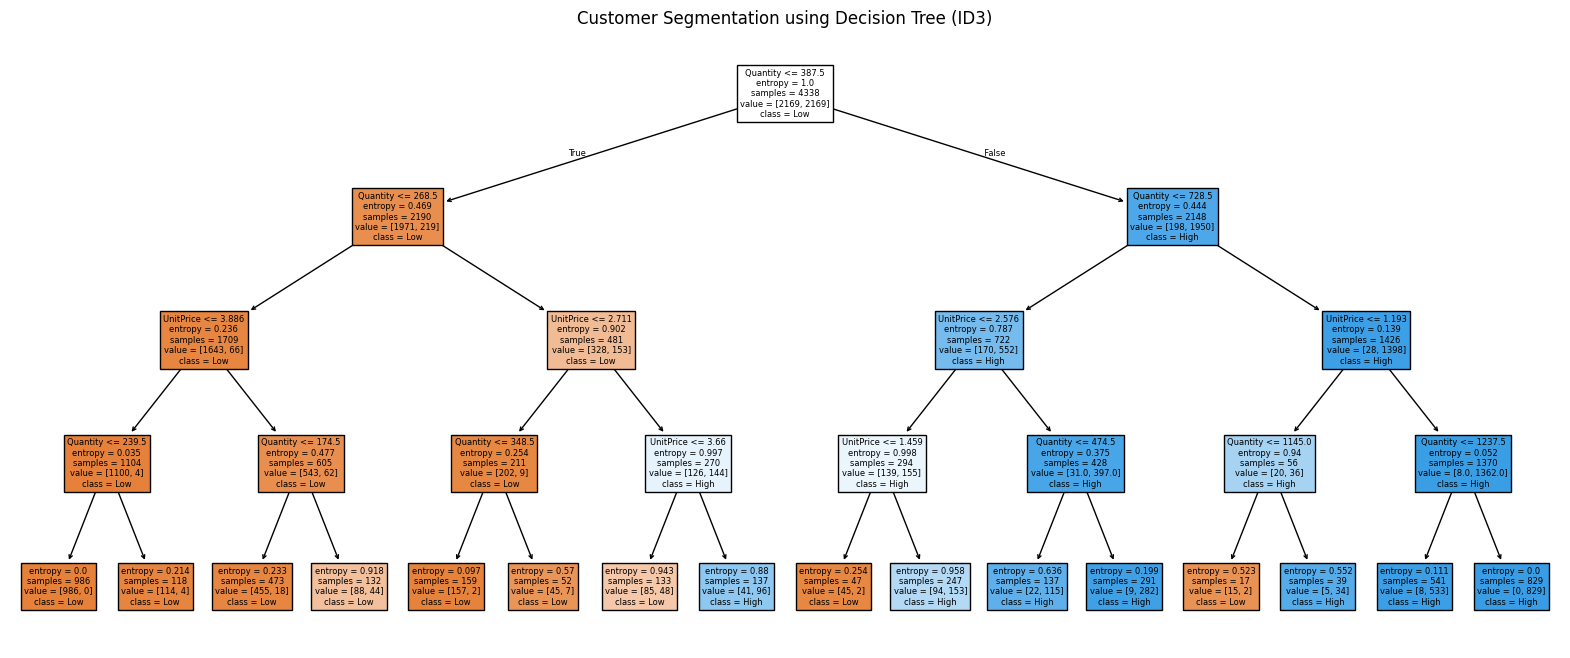

In [10]:
# 8. Visualization 
# ------------------------------- 
plt.figure(figsize=(20,8)) 
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
)
model.fit(X, y)

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Low', 'High'],
    filled=True
)
plt.title("Customer Segmentation using Decision Tree (ID3)") 
plt.show() 
# -------------------------------

In [11]:
# 9. Feature Importance 
# ------------------------------- 
importance = pd.Series(model.feature_importances_, index=X.columns) 
print("\nFeature Importance:\n", importance.sort_values(ascending=False))


Feature Importance:
 Quantity     0.86527
UnitPrice    0.13473
Country      0.00000
dtype: float64
